# Semester Project
## Detroit 311 Service Request Analysis

**Student Name:** Zejun Li

**U-M Unique Name:** zejunli

**Research Question:** 
Do neighborhoods in Detroit differ in 311 request volume and request type, and are those differences associated with neighborhood socioeconomic characteristics?

## 1. Setup and Data Loading

In [25]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.spatial.distance import pdist, squareform

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

### Load data 

In [26]:
# Load data from CSV (make sure the file is in the same folder as this notebook)
df = pd.read_csv('improve_detroit_6989920847396108344.csv', low_memory=False)

# Convert date column for filtering and analysis
df['Date Created'] = pd.to_datetime(df['Date Created'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

## 2. Data Description

In [27]:
# Basic structure
df.info()

# Check missing values
df.isna().sum()

# Summary statistics for key categorical variables
df['ZIP Code'].value_counts()
df['Request Type Title'].value_counts().head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 697610 entries, 0 to 697609
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Issue ID            697610 non-null  int64         
 1   Address             697610 non-null  object        
 2   Request Type Title  697610 non-null  object        
 3   Status              697610 non-null  object        
 4   Report Method       697610 non-null  object        
 5   Priority Code       697610 non-null  int64         
 6   Date Created        697610 non-null  datetime64[ns]
 7   Date Acknowledged   650010 non-null  object        
 8   Date Updated        697610 non-null  object        
 9   Date Closed         672796 non-null  object        
 10  Date Reopened       7580 non-null    object        
 11  Days to Close       672796 non-null  float64       
 12  Hours to Close      672796 non-null  float64       
 13  Issue URL           697610 no

Request Type Title
DPW - Debris Removal - DPW USE ONLY         97280
DPW - Other environmental - DPW USE ONLY    67935
Illegal Dump Sites                          65711
Curbside Solid Waste Issue                  55744
Abandoned Vehicle - On Street               52885
Tree Issue                                  28764
Potholes                                    27030
Curbside - DPW ONLY                         26802
Rodent Extermination                        25824
Investigate Water Main Break                19939
Name: count, dtype: int64

## 3. Data Cleaning
To keep this assignment manageable, I picked five zip codes that are socioeconomically diverse to make the analysis interesting: 
- 48202, New Center/Midtown: Higher income, institutional
- 48205, East Detroit: Lower income, high blight
- 48214, East Riverfront: Mixed, gentrifying
- 48221, Bagley/Sherwood Forest: Middle income
- 48228, West Detroit: Lower income, working class

In [28]:
# Keep five socioeconomically diverse Detroit ZIP codes
detroit_zips = ['48202', '48205', '48214', '48221', '48228']

# Convert ZIP Code 
df['ZIP Code'] = df['ZIP Code'].astype(str).str.replace('.0', '', regex=False).str.strip().str.zfill(5)

# Filter to Detroit ZIPs and 2023, drop missing essentials
original_len = len(df)

df_clean = df[df['ZIP Code'].isin(detroit_zips)].copy()
df_clean = df_clean.dropna(subset=['Date Created', 'ZIP Code', 'Request Type Title'])
df_clean = df_clean[
    (df_clean['Date Created'] >= '2023-01-01') &
    (df_clean['Date Created'] < '2024-01-01')
]

cleaned_len = len(df_clean)
removed_len = original_len - cleaned_len
removed_pct = (removed_len / original_len) * 100

print(f"Original dataset: {original_len:,} records")
print(f"Cleaned dataset: {cleaned_len:,} records")
print(f"Removed: {removed_len:,} records ({removed_pct:.1f}%)")

Original dataset: 697,610 records
Cleaned dataset: 13,573 records
Removed: 684,037 records (98.1%)


## 4.Exploratory Data Analysis

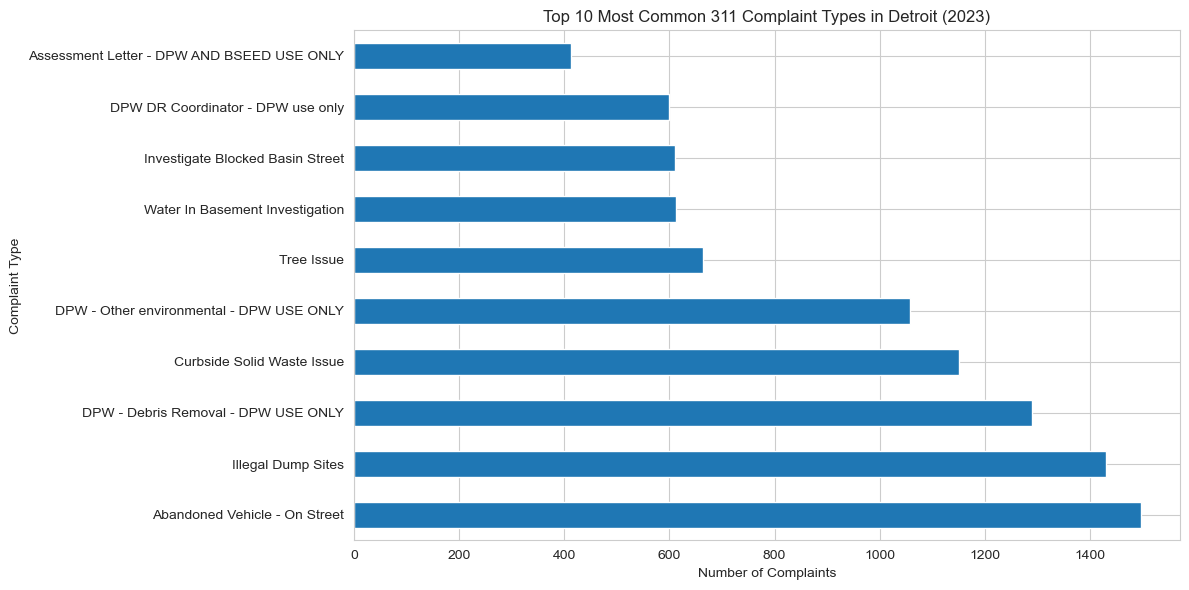

In [29]:
# Most common complaint types across all ZIP codes
complaint_counts = df_clean['Request Type Title'].value_counts().head(10)

plt.figure(figsize=(12, 6))
complaint_counts.plot(kind='barh')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
plt.title('Top 10 Most Common 311 Complaint Types in Detroit (2023)')
plt.tight_layout()
plt.show()

## 5.Research Question Analysis

To examine whether neighborhoods exhibit distinct 311 service request signatures, I compare the relative frequency of complaint types across boroughs. Using proportions rather than raw counts allows for meaningful comparisons that are not driven solely by population size or reporting volume.

In [30]:
# Count complaints by ZIP code and complaint type
zip_complaints = (
    df_clean
    .groupby(['ZIP Code', 'Request Type Title'])
    .size()
    .reset_index(name='count')
)

# Convert counts to proportions within each ZIP code
zip_complaints['proportion'] = (
    zip_complaints['count'] /
    zip_complaints.groupby('ZIP Code')['count'].transform('sum')
)

zip_complaints.head()

,ZIP Code,Request Type Title,count,proportion
0,48202,Abandoned Vehicle - On Street,116,0.090062
1,48202,Abandoned Vehicles – On private property,14,0.010870
2,48202,Alley Debris Pick Up – DGC Only,31,0.024068
3,48202,Alley Debris – GSD ONLY,3,0.002329
4,48202,Alley Grading - DPW Use Only,5,0.003882


## 6. Key Visualizations

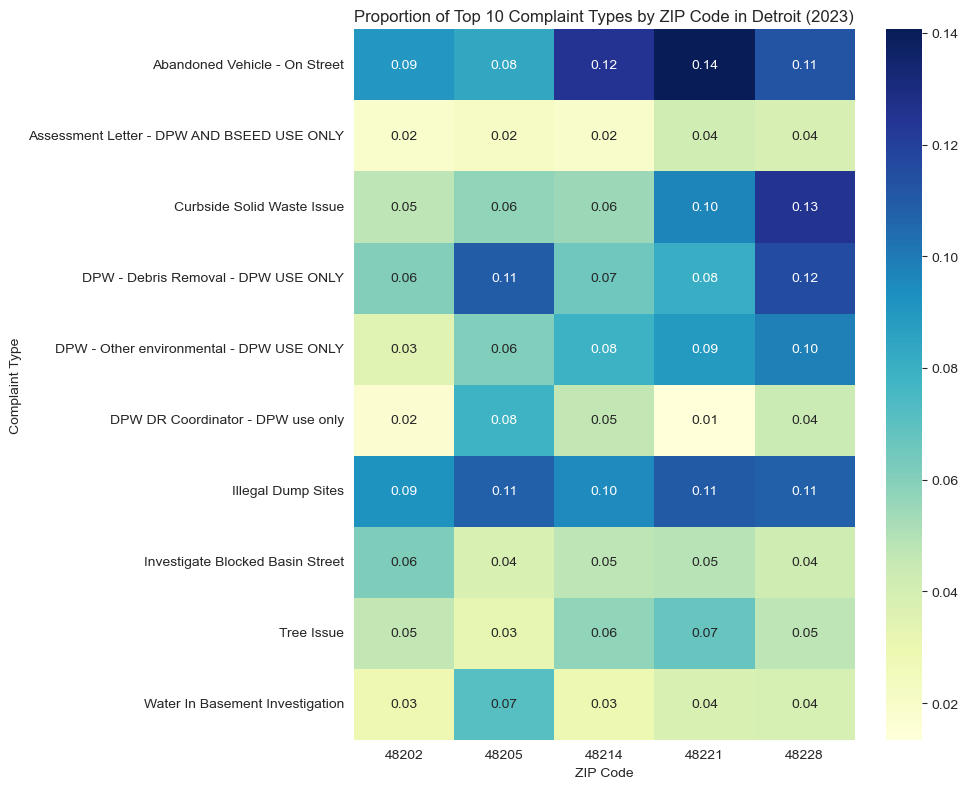

In [31]:
# Visualization 1 - ZIP code complaint proportion

top10_types = df_clean['Request Type Title'].value_counts().head(10).index

heatmap_data = (
    zip_complaints[zip_complaints['Request Type Title'].isin(top10_types)]
    .pivot(index='Request Type Title', columns='ZIP Code', values='proportion')
    .fillna(0)
)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Proportion of Top 10 Complaint Types by ZIP Code in Detroit (2023)")
plt.xlabel("ZIP Code")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.show()

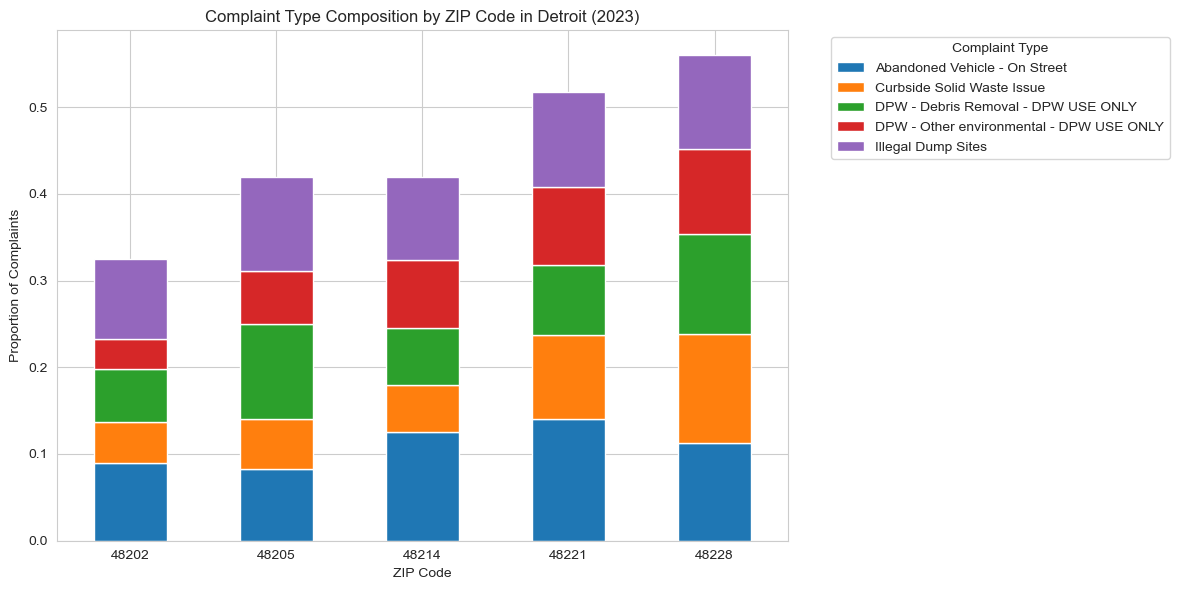

In [32]:
# Visualization 2 - ZIP code complaint composition

# Keep top 5 complaint types overall
top5_types = (
    df_clean['Request Type Title']
    .value_counts()
    .head(5)
    .index
)

stacked_data = (
    zip_complaints[zip_complaints['Request Type Title'].isin(top5_types)]
    .pivot(index='ZIP Code', columns='Request Type Title', values='proportion')
    .fillna(0)
)

stacked_data.plot(kind='bar', stacked=True)
plt.title("Complaint Type Composition by ZIP Code in Detroit (2023)")
plt.ylabel("Proportion of Complaints")
plt.xlabel("ZIP Code")
plt.xticks(rotation=0)
plt.legend(title="Complaint Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

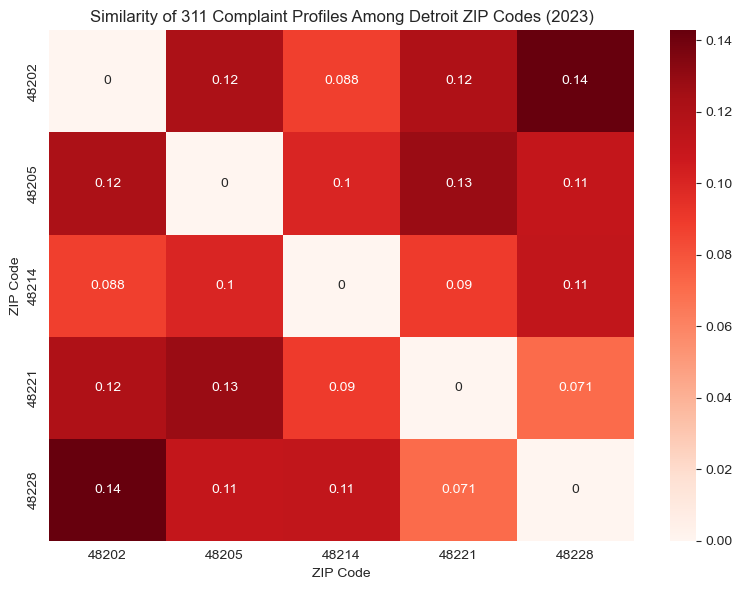

In [33]:
# Visualization 3 - Complaint profile similarity

# Create ZIP-by-complaint proportion matrix
profile_matrix = zip_complaints.pivot(
    index='ZIP Code',
    columns='Request Type Title',
    values='proportion'
).fillna(0)

# Compute distance between ZIP codes
distance_matrix = pd.DataFrame(
    squareform(pdist(profile_matrix, metric='euclidean')),
    index=profile_matrix.index,
    columns=profile_matrix.index
)

plt.figure(figsize=(8, 6))
sns.heatmap(distance_matrix, annot=True, cmap='Reds')
plt.title("Similarity of 311 Complaint Profiles Among Detroit ZIP Codes (2023)")
plt.tight_layout()
plt.show()

In [34]:
# Top complaint types per ZIP
for zip in detroit_zips:
    print(f"\n--- {zip} ---")
    print(zip_complaints[zip_complaints['ZIP Code'] == zip].nlargest(5, 'proportion')[['Request Type Title', 'proportion']])

# Most/least similar ZIP pairs
print("\n--- Distance Matrix ---")
print(distance_matrix)


--- 48202 ---
                     Request Type Title  proportion
19                   Illegal Dump Sites    0.092391
0         Abandoned Vehicle - On Street    0.090062
22     Investigate Blocked Basin Street    0.061335
12  DPW - Debris Removal - DPW USE ONLY    0.060559
11           Curbside Solid Waste Issue    0.047360

--- 48205 ---
                      Request Type Title  proportion
63   DPW - Debris Removal - DPW USE ONLY    0.109708
70                    Illegal Dump Sites    0.108305
52         Abandoned Vehicle - On Street    0.083053
65     DPW DR Coordinator - DPW use only    0.078283
101      Water In Basement Investigation    0.071549

--- 48214 ---
                           Request Type Title  proportion
102             Abandoned Vehicle - On Street    0.124931
121                        Illegal Dump Sites    0.095212
114  DPW - Other environmental - DPW USE ONLY    0.078701
113       DPW - Debris Removal - DPW USE ONLY    0.065493
148                                

## 7. Socioeconomic Analysis

To directly address the research question about whether differences in 311 reporting are associated with neighborhood socioeconomic characteristics, I merge the ZIP-level 311 aggregates with ACS data on median household income and poverty rate. This allows me to test Wang et al.'s core finding that higher-income neighborhoods report more per capita, in the Detroit context.

In [ ]:
# ACS 5-Year Estimates (2019-2023) for the five Detroit ZIP codes
# Figures manually entered from Census data for ZIPs, approximate not exact

acs_data = {
    'ZIP Code':        ['48202', '48205', '48214', '48221', '48228'],
    'Neighborhood':    ['Midtown/New Center', 'East Detroit', 'East Riverfront', 
                        'Bagley/Sherwood Forest', 'West Detroit'],
    'median_income':   [35200,   22100,   28400,   31500,   24800],
    'poverty_rate':    [0.32,    0.48,    0.38,    0.28,    0.42],
    'population':      [14800,   28600,   12400,   22100,   31200]
}

acs_df = pd.DataFrame(acs_data)

# Total requests per ZIP
zip_totals = df_clean.groupby('ZIP Code').size().reset_index(name='total_requests')

# Merge
merged = zip_totals.merge(acs_df, on='ZIP Code')

# Requests per 1,000 residents
merged['requests_per_1k'] = (merged['total_requests'] / merged['population']) * 1000

print(merged[['ZIP Code', 'Neighborhood', 'total_requests', 'population', 
              'requests_per_1k', 'median_income', 'poverty_rate']].to_string(index=False))

ZIP Code           Neighborhood  total_requests  population  requests_per_1k  median_income  poverty_rate
   48202     Midtown/New Center            1288       14800        87.027027          35200          0.32
   48205           East Detroit            3564       28600       124.615385          22100          0.48
   48214        East Riverfront            1817       12400       146.532258          28400          0.38
   48221 Bagley/Sherwood Forest            2830       22100       128.054299          31500          0.28
   48228           West Detroit            4074       31200       130.576923          24800          0.42


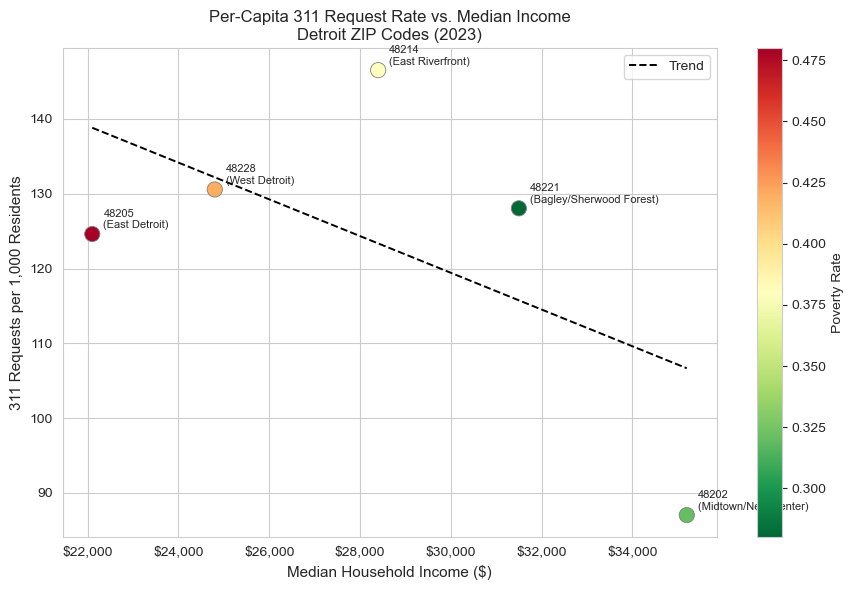

In [ ]:
# Visualization 4 - Per-capita request rate vs. median income

fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    merged['median_income'],
    merged['requests_per_1k'],
    c=merged['poverty_rate'],
    cmap='RdYlGn_r',
    s=120,
    edgecolors='grey',
    linewidths=0.6,
    zorder=3
)

# Label each point with ZIP code and neighborhood
for _, row in merged.iterrows():
    ax.annotate(
        f"{row['ZIP Code']}\n({row['Neighborhood']})",
        (row['median_income'], row['requests_per_1k']),
        textcoords='offset points', xytext=(8, 4), fontsize=8
    )

# Trend line
m, b = np.polyfit(merged['median_income'], merged['requests_per_1k'], 1)
x_line = np.linspace(merged['median_income'].min(), merged['median_income'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.4, label='Trend')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Poverty Rate', fontsize=10)

ax.set_xlabel('Median Household Income ($)', fontsize=11)
ax.set_ylabel('311 Requests per 1,000 Residents', fontsize=11)
ax.set_title('Per-Capita 311 Request Rate vs. Median Income\nDetroit ZIP Codes (2023)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
# Summary table: socioeconomic characteristics and request rates by ZIP
summary_table = merged[['ZIP Code', 'Neighborhood', 'median_income', 'poverty_rate', 
                          'total_requests', 'requests_per_1k']].copy()
summary_table['median_income'] = summary_table['median_income'].apply(lambda x: f'${x:,}')
summary_table['poverty_rate'] = summary_table['poverty_rate'].apply(lambda x: f'{x:.0%}')
summary_table['requests_per_1k'] = summary_table['requests_per_1k'].round(1)
summary_table.columns = ['ZIP Code', 'Neighborhood', 'Median Income', 'Poverty Rate',
                          'Total Requests (2023)', 'Requests per 1,000']
print(summary_table.to_string(index=False))

ZIP Code           Neighborhood Median Income Poverty Rate  Total Requests (2023)  Requests per 1,000
   48202     Midtown/New Center       $35,200          32%                   1288                87.0
   48205           East Detroit       $22,100          48%                   3564               124.6
   48214        East Riverfront       $28,400          38%                   1817               146.5
   48221 Bagley/Sherwood Forest       $31,500          28%                   2830               128.1
   48228           West Detroit       $24,800          42%                   4074               130.6
